# Credit Score Classification

| Section | เนื้อหา |
|---|---|
| 1 | Setup & Imports |
| 2 | Load Data |
| 3 | Data Cleaning |
| 4 | EDA |
| 5 | WOE Encoding + IV Feature Selection |
| 6 | Model Training & Evaluate |
| 7 | Predict & Export |

## 1. Setup & Imports

In [1]:
!pip install optbinning

import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import  cross_val_score, train_test_split, GridSearchCV
from sklearn.metrics import f1_score, classification_report
from optbinning import OptimalBinning
from statsmodels.stats.outliers_influence import variance_inflation_factor


print("Setup complete")

Setup complete


## 2. Load Data

In [2]:
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')
print(f"Train: {train_df.shape}, Test: {test_df.shape}")

Train: (80000, 28), Test: (20000, 28)


## 3. Data Cleaning

In [3]:
import re
def extract_months(text):
    if pd.isna(text) or str(text).strip().lower() == 'nan':
        return np.nan
    nums = re.findall(r'\d+', str(text))
    if len(nums) == 2: # Years and Months
        return int(nums[0]) * 12 + int(nums[1])
    elif len(nums) == 1: # Years only
        return int(nums[0]) * 12
    return np.nan

for df in [train_df, test_df]:
    df['Credit_History_Age_Months'] = df['Credit_History_Age'].apply(extract_months)

In [4]:
# 3.1 Dirty strings -> NaN
for df in [train_df, test_df]:
    df['Occupation']        = df['Occupation'].replace('_______', np.nan)
    df['Credit_Mix']        = df['Credit_Mix'].replace('_', np.nan)
    df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', np.nan)

In [5]:
# 3.2 Convert String -> Numeric
dirty_num_cols = [
    'Age','Annual_Income','Num_of_Loan','Num_of_Delayed_Payment',
    'Changed_Credit_Limit','Outstanding_Debt','Monthly_Inhand_Salary',
    'Num_Bank_Accounts','Num_Credit_Card','Interest_Rate',
    'Delay_from_due_date','Num_Credit_Inquiries','Credit_Utilization_Ratio',
    'Total_EMI_per_month','Amount_invested_monthly','Monthly_Balance','Credit_History_Age_Months'
]
for col in dirty_num_cols:
    for df in [train_df, test_df]:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(r'[^0-9.\-]', '', regex=True),
            errors='coerce'
        )

In [6]:
# 3.3 Outlier -> NaN
for df in [train_df, test_df]:
    for col in ['Age','Annual_Income','Monthly_Inhand_Salary','Num_Bank_Accounts',
                'Num_Credit_Card','Interest_Rate','Num_of_Loan','Delay_from_due_date',
                'Num_of_Delayed_Payment','Outstanding_Debt','Total_EMI_per_month',
                'Amount_invested_monthly','Monthly_Balance','Credit_History_Age_Months']:
        df.loc[df[col] < 0, col] = np.nan

    df.loc[df['Age'] > 100,              'Age']               = np.nan
    df.loc[df['Num_Bank_Accounts'] > 20, 'Num_Bank_Accounts'] = np.nan
    df.loc[df['Num_Credit_Card'] > 20,   'Num_Credit_Card']   = np.nan
    df.loc[df['Interest_Rate'] > 100,    'Interest_Rate']     = np.nan
    df.loc[df['Num_of_Loan'] > 20,       'Num_of_Loan']       = np.nan

## 4. EDA

In [7]:
# 4.1 Missing values
missing = train_df.isnull().sum()
print("Missing Values:")
print(missing[missing > 0].sort_values(ascending=False))

Missing Values:
Credit_Mix                   16158
Monthly_Inhand_Salary        11962
Type_of_Loan                  9213
Name                          8008
Credit_History_Age            7223
Credit_History_Age_Months     7223
Num_of_Delayed_Payment        6144
Payment_Behaviour             6098
Occupation                    5646
Amount_invested_monthly       3530
Num_of_Loan                   3456
Age                           2226
Num_Credit_Card               1814
Changed_Credit_Limit          1654
Num_Credit_Inquiries          1579
Interest_Rate                 1549
Num_Bank_Accounts             1052
Monthly_Balance                946
Delay_from_due_date            463
dtype: int64


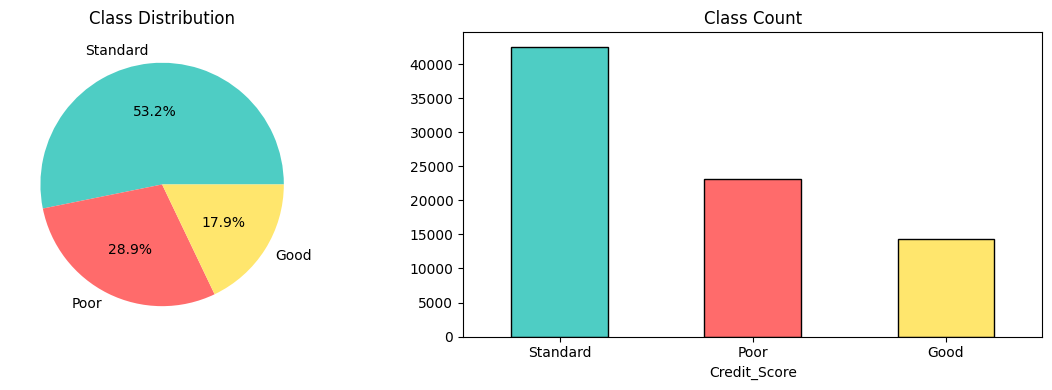

In [8]:
# 4.2 Class distribution - Train
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = train_df['Credit_Score'].value_counts()
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#4ecdc4','#ff6b6b','#ffe66d'])
axes[0].set_title('Class Distribution')
counts.plot(kind='bar', ax=axes[1], color=['#4ecdc4','#ff6b6b','#ffe66d'], edgecolor='black')
axes[1].set_title('Class Count')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 5. WOE Encoding + IV Feature Selection

ใช้ `OptimalBinning` แปลง feature ทุกตัวเป็น WOE (Weight of Evidence)

- WOE ต้องการ **binary target**: `Poor = 1`, `Good / Standard = 0`
- IV (Information Value) > 0.02 = feature มีประโยชน์

In [9]:
# Flag Target Y
train_df['target_bin'] = train_df['Credit_Score'].map({
    'Good': 0,
    'Standard': 0,
    'Poor': 1
})

In [10]:
X = train_df.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN', 'Month', 'Credit_Score', 'target_bin'])
y = train_df['Credit_Score']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,      #(ใช้ stratify = y - balance class)
    random_state=42
)

# 3. สร้าง y_train_bin เฉพาะกิจ (เพื่อเอาไปใช้ Fit WoE เท่านั้น)
y_train_bin = (y_train == 'Poor').astype(int)

In [11]:
# Encoding
# 1. เตรียมตัวแปรเก็บผลลัพธ์
iv_records = []
X_train_woe = pd.DataFrame(index=X_train.index)
X_test_woe = pd.DataFrame(index=X_test.index)
binning_models = {} # เก็บ model ไว้ใช้ transform test set หรือข้อมูลใหม่

# 2. วนลูปทุก Feature ใน X_train
for col in X_train.columns:
    # แยกประเภทข้อมูลเบื้องต้น
    dtype_opt = "numerical" if X_train[col].dtype != 'object' else "categorical"

    # สร้างและ Fit OptimalBinning
    # ใช้ solver='cp' เพื่อความเร็วและแม่นยำ
    optb = OptimalBinning(name=col, dtype=dtype_opt, solver="cp")
    optb.fit(X_train[col].values, y_train_bin)

    #สั่ง build ตารางสรุปผล
    binning_table = optb.binning_table
    binning_table.build()

    # บันทึกค่า IV และ Model
    iv_records.append({'Feature': col, 'IV': optb.binning_table.iv})
    binning_models[col] = optb

    # แปลงข้อมูลเป็นค่า WoE ใส่ใน DataFrame ใหม่
    X_train_woe[col] = optb.transform(X_train[col].values, metric="woe")
    X_test_woe[col] = optb.transform(X_test[col].values, metric="woe")

# 3. สรุปผลค่า IV (Information Value) - Predictive Power
iv_df = pd.DataFrame(iv_records).sort_values(by='IV', ascending=False)
print("Information Value (IV) Summary:")
print(iv_df)

Information Value (IV) Summary:
                      Feature        IV
8                Type_of_Loan  5.357534
14           Outstanding_Debt  1.248367
6               Interest_Rate  1.056417
12       Num_Credit_Inquiries  0.833012
9         Delay_from_due_date  0.737249
16         Credit_History_Age  0.656774
22  Credit_History_Age_Months  0.617796
5             Num_Credit_Card  0.617628
7                 Num_of_Loan  0.577715
13                 Credit_Mix  0.540390
4           Num_Bank_Accounts  0.516193
17      Payment_of_Min_Amount  0.391695
10     Num_of_Delayed_Payment  0.327244
2               Annual_Income  0.273357
21            Monthly_Balance  0.216238
3       Monthly_Inhand_Salary  0.190257
0                         Age  0.146269
18        Total_EMI_per_month  0.122178
20          Payment_Behaviour  0.054926
19    Amount_invested_monthly  0.052109
11       Changed_Credit_Limit  0.034336
15   Credit_Utilization_Ratio  0.014168
1                  Occupation  0.003921


In [12]:
# 1. คัดเลือก Feature ที่ผ่านเกณฑ์ IV เบื้องต้น (> 0.02)
selected_features = iv_df[iv_df['IV'] > 0.1]['Feature'].tolist()

# 2. คำนวณ VIF จาก X_train_woe เฉพาะคอลัมน์ที่เลือก
X_vif_check = X_train_woe[selected_features]
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif_check.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif_check.values, i) for i in range(len(X_vif_check.columns))]

# 3. นำค่า IV จาก iv_df มา Merge รวมกับ VIF
# (สมมติ iv_df ของนักเรียนมีคอลัมน์ 'Feature' และ 'IV')
final_report = vif_data.merge(iv_df[['Feature', 'IV']], on='Feature')

# 4. จัดเรียงตาม IV (ตัวที่เก่งที่สุดอยู่บน)
final_report = final_report.sort_values(by='IV', ascending=False).reset_index(drop=True)

print("--- Feature Selection Report (IV & VIF) ---")
print(final_report)

--- Feature Selection Report (IV & VIF) ---
                      Feature        VIF        IV
0                Type_of_Loan   1.249144  5.357534
1            Outstanding_Debt   3.551600  1.248367
2               Interest_Rate   2.836058  1.056417
3        Num_Credit_Inquiries   2.514457  0.833012
4         Delay_from_due_date   2.208390  0.737249
5          Credit_History_Age  16.692320  0.656774
6   Credit_History_Age_Months  17.732779  0.617796
7             Num_Credit_Card   1.666776  0.617628
8                 Num_of_Loan   3.003506  0.577715
9                  Credit_Mix   2.663294  0.540390
10          Num_Bank_Accounts   2.110753  0.516193
11      Payment_of_Min_Amount   1.946939  0.391695
12     Num_of_Delayed_Payment   1.791816  0.327244
13              Annual_Income   4.045057  0.273357
14            Monthly_Balance   1.938927  0.216238
15      Monthly_Inhand_Salary   3.775566  0.190257
16                        Age   1.180742  0.146269
17        Total_EMI_per_month   1.4524

In [13]:
# 1. รายชื่อตัวแปรที่จะตัดออก (เริ่มจากตัวที่ VIF สูงสุดและซ้ำซ้อนชัดเจน)
cols_to_drop = ['Credit_History_Age']

# 2. อัปเดต List ของ Selected Features
final_features = [f for f in selected_features if f not in cols_to_drop]

# 3. รัน VIF อีกรอบเพื่อความชัวร์
X_vif_final = X_train_woe[final_features]
vif_result_final = pd.DataFrame()
vif_result_final["Feature"] = X_vif_final.columns
vif_result_final["VIF"] = [variance_inflation_factor(X_vif_final.values, i) for i in range(len(X_vif_final.columns))]

vif_result_final = vif_result_final.merge(iv_df[['Feature', 'IV']], on='Feature').sort_values(by='IV', ascending=False)

print("VIF Result After Cleaning:")
print(vif_result_final)

VIF Result After Cleaning:
                      Feature       VIF        IV
0                Type_of_Loan  1.246785  5.357534
1            Outstanding_Debt  3.551597  1.248367
2               Interest_Rate  2.835957  1.056417
3        Num_Credit_Inquiries  2.514116  0.833012
4         Delay_from_due_date  2.208379  0.737249
5   Credit_History_Age_Months  2.255123  0.617796
6             Num_Credit_Card  1.666748  0.617628
7                 Num_of_Loan  3.003395  0.577715
8                  Credit_Mix  2.662261  0.540390
9           Num_Bank_Accounts  2.110749  0.516193
10      Payment_of_Min_Amount  1.946321  0.391695
11     Num_of_Delayed_Payment  1.791789  0.327244
12              Annual_Income  4.044854  0.273357
13            Monthly_Balance  1.938916  0.216238
14      Monthly_Inhand_Salary  3.775488  0.190257
15                        Age  1.180727  0.146269
16        Total_EMI_per_month  1.452082  0.122178


In [14]:
# อัปเดตตัวแปรที่จะใช้เทรนจริง
X_train_final = X_train_woe[final_features]
X_test_final = X_test_woe[final_features]

print(f"Train model {len(final_features)} Features")

Train model 17 Features


## 6. Model Training & Evaluate



In [15]:
model_params = {
    'Logistic_Regression': {
        'model': LogisticRegression(multi_class='multinomial', class_weight='balanced', solver='lbfgs', max_iter=2000, random_state=42),
        'params': {'C': [0.1, 1, 10, 100]}
    },
    'Naive_Bayes': {
        'model': GaussianNB(),
        'params': {} # Naive Bayes ปกติไม่ต้องจูนค่า Parameter หลัก
    }
}

# 2. วนลูปเพื่อหาตัวที่ดีที่สุดของแต่ละฝั่ง
scores = []

for model_name, mp in model_params.items():
    grid = GridSearchCV(mp['model'], mp['params'], cv=5, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_train_woe[final_features], y_train)
    scores.append({
        'Model': model_name,
        'Best_Score_F1': grid.best_score_,
        'Best_Params': grid.best_params_
    })

# 3. สร้างตารางสรุปผลเปรียบเทียบ (ไว้ออก Report)
comparison_df = pd.DataFrame(scores)
print("--- Model Comparison Results ---")
print(comparison_df)



--- Model Comparison Results ---
                 Model  Best_Score_F1 Best_Params
0  Logistic_Regression       0.671993  {'C': 0.1}
1          Naive_Bayes       0.596087          {}


In [16]:
best_model = LogisticRegression(
    C=0.1,
    multi_class='multinomial',
    class_weight='balanced',
    solver='lbfgs',
    max_iter=2000,
    random_state=42
)

# 2. เทรน (Fit) ด้วยข้อมูล Train ทั้งหมดอีกครั้งเพื่อให้โมเดลพร้อมที่สุด
best_model.fit(X_train_woe[final_features], y_train)


LogisticRegression(C=0.1, class_weight='balanced', max_iter=2000,
                   multi_class='multinomial', random_state=42)

In [17]:
y_train_pred = best_model.predict(X_train_woe[final_features])
print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

        Good       0.43      0.80      0.56     11457
        Poor       0.76      0.80      0.78     18513
    Standard       0.84      0.57      0.68     34030

    accuracy                           0.68     64000
   macro avg       0.68      0.72      0.67     64000
weighted avg       0.74      0.68      0.69     64000



In [18]:
# Test Set 20%
y_test_pred = best_model.predict(X_test_woe[final_features])
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

        Good       0.43      0.82      0.56      2865
        Poor       0.73      0.77      0.75      4628
    Standard       0.83      0.55      0.66      8507

    accuracy                           0.66     16000
   macro avg       0.66      0.71      0.66     16000
weighted avg       0.73      0.66      0.67     16000



## 7. Predict & Export

In [19]:
submission_full = test_df.copy()

X_real_test_woe = pd.DataFrame()
for col in final_features:
    X_real_test_woe[col] = binning_models[col].transform(test_df[col].values, metric="woe")

real_predictions = best_model.predict(X_real_test_woe)

submission_full['Credit_Score'] = real_predictions

if 'Credit_History_Age_Months' in submission_full.columns:
    submission_full = submission_full.drop(columns=['Credit_History_Age_Months'])


submission_full.to_csv('result_credit_scoring.csv', index=False)


